In [1]:
!unzip /content/masks.zip

Archive:  /content/masks.zip
   creating: content/masks/
  inflating: content/masks/17_mask.png  
  inflating: content/masks/16_mask.png  
  inflating: content/masks/13_mask.png  
  inflating: content/masks/1_mask.png  
  inflating: content/masks/4_mask.png  
  inflating: content/masks/18_mask.png  
  inflating: content/masks/11_mask.png  
  inflating: content/masks/10_mask.png  
  inflating: content/masks/15_mask.png  
  inflating: content/masks/12_mask.png  
  inflating: content/masks/3_mask.png  
  inflating: content/masks/2_mask.png  
  inflating: content/masks/23_mask.png  
  inflating: content/masks/8_mask.png  
  inflating: content/masks/21_mask.png  
  inflating: content/masks/22_mask.png  
  inflating: content/masks/20_mask.png  
  inflating: content/masks/7_mask.png  
  inflating: content/masks/14_mask.png  
  inflating: content/masks/9_mask.png  
  inflating: content/masks/19_mask.png  
  inflating: content/masks/5_mask.png  
  inflating: content/masks/6_mask.png  


In [2]:
import cv2
import numpy as np

images = []
masks = []

for i in range(1,24):
  img = cv2.imread(f'/content/drive/MyDrive/Comic_Marvel/{i}.png')
  mask = cv2.imread(f'/content/content/masks/{i}_mask.png',cv2.IMREAD_GRAYSCALE)
  img = cv2.resize(img, (128, 128))
  mask = cv2.resize(mask, (128, 128))
  img = img / 255.0
  mask = mask / 255.0
  images.append(img)
  masks.append(mask)

images = np.array(images)
masks = np.array(masks)

masks = np.expand_dims(masks, axis=-1)

In [10]:
from sklearn.model_selection import train_test_split

train_images, val_images, train_masks, val_masks = train_test_split(images, masks, test_size=5, random_state=42)

In [4]:
from tensorflow.keras.layers import Input, Conv2D, MaxPool2D, UpSampling2D, concatenate, Conv2DTranspose
from tensorflow.keras.models import Model

In [5]:
def double_conv_block(x, n_filters):
    x = Conv2D(n_filters, 3, padding='same', activation='relu', kernel_initializer='he_normal')(x)
    x = Conv2D(n_filters, 3, padding='same', activation='relu', kernel_initializer='he_normal')(x)
    return x

def downsample_block(x, n_filters):
    f = double_conv_block(x, n_filters)
    p = MaxPool2D(2)(f)
    # p = Dropout(0.3)(p)
    return f, p

def upsample_block(x, conv_features, n_filters):
    x = Conv2DTranspose(n_filters, 3, 2, padding='same')(x)
    x = concatenate([x, conv_features])
    # x = Dropout(0.3)(x)
    x = double_conv_block(x, n_filters)
    return x

In [8]:
def unet(output_channels):
    inputs = Input(shape=(128, 128, 3))

    f1, p1 = downsample_block(inputs, 64)
    f2, p2 = downsample_block(p1, 128)
    f3, p3 = downsample_block(p2, 256)
    f4, p4 = downsample_block(p3, 512)

    intermediate_block = double_conv_block(p4, 1024)

    u6 = upsample_block(intermediate_block, f4, 512)
    u7 = upsample_block(u6, f3, 256)
    u8 = upsample_block(u7, f2, 128)
    u9 = upsample_block(u8, f1, 64)

    outputs = Conv2D(output_channels, 1, padding='same', activation='sigmoid')(u9)

    unet_model = Model(inputs, outputs, name='U-Net')

    return unet_model

output_channels = 1
model = unet(output_channels)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [11]:
history = model.fit(train_images, train_masks,validation_data=(val_images, val_masks),epochs=20,batch_size=4)

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 46s 10s/step - accuracy: 0.7411 - loss: 0.5161 - val_accuracy: 0.8232 - val_loss: 0.3943
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 39s 107ms/step - accuracy: 0.7459 - loss: 0.5375 - val_accuracy: 0.8210 - val_loss: 0.3947
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.7343 - loss: 0.5164 - val_accuracy: 0.8206 - val_loss: 0.4504
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.7244 - loss: 0.5265 - val_accuracy: 0.8213 - val_loss: 0.4195
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.7328 - loss: 0.5057 - val_accuracy: 0.8191 - val_loss: 0.4390
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step - accuracy: 0.7468 - loss: 0.5119 - val_accuracy: 0.8245 - val_loss: 0.3984
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 103ms/step - accuracy: 0.7272 - loss: 0.5171 - val_accuracy: 0.8213 - val_loss: 0.4001
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - accuracy: 0.7600 - loss: 0.4954 - val_accuracy: 0.8315 - val_loss: 0.

In [12]:
model.save('unet_3.h5')

In [13]:
def calculate_iou(y_true, y_pred):
    y_true = y_true > 0.5
    y_pred = y_pred > 0.5

    intersection = np.logical_and(y_true, y_pred)
    union = np.logical_or(y_true, y_pred)
    iou = np.sum(intersection) / np.sum(union)
    return iou

val_preds = model.predict(val_images)

ious = [calculate_iou(val_masks[i], val_preds[i]) for i in range(len(val_images))]
print(f"Mean IoU: {np.mean(ious)}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
Mean IoU: 0.3226484483692186


In [14]:
new_image = cv2.imread('/content/drive/MyDrive/Comic_Marvel/1.png')
new_image = cv2.resize(new_image, (128, 128)) / 255.0
new_image = np.expand_dims(new_image, axis=0)

pred_mask = model.predict(new_image)
pred_mask = (pred_mask > 0.5).astype(np.uint8)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 969ms/step


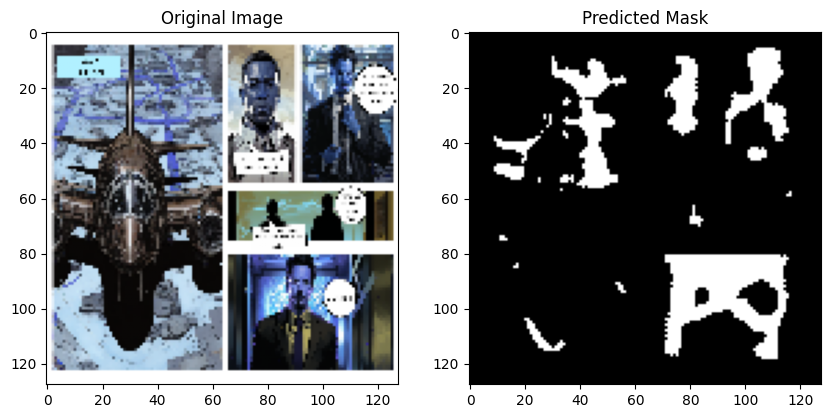

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(new_image[0])

plt.subplot(1, 2, 2)
plt.title("Predicted Mask")
plt.imshow(pred_mask[0, :, :, 0], cmap='gray')
plt.show()